# Generation of disentangled matrix on visiumHD CRC data P5

## Import libraries

In [1]:
import spatialdata as sd
import squidpy as sq

/software/cellgen/team361/ms83/envs/env_Dec11th_mintflowandrapids/lib/python3.11/importlib/__init__.py:126: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  return _bootstrap._gcd_import(name[level:], package, level)
/software/cellgen/team361/ms83/envs/env_Dec11th_mintflowandrapids/lib/python3.11/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import scanpy as sc
import anndata as ad
import numpy as np
import pandas as pd

In [3]:
from sklearn.decomposition import PCA

In [4]:
import rapids_singlecell as rsc

In [5]:
import os, sys
import pickle
import torch
from scipy.sparse import issparse
import gc
from pprint import pprint
from tqdm.autonotebook import tqdm

In [6]:
import mintflow
import mintflow.interface.perturbation.module_gen_micsizefactor
import mintflow.interface.perturbation.module_gen_stdata

## Paths

In [7]:
path_output_files = "/nfs/team361/ms83/data/CRC/visiumHD_mintflow/Outputs_nb1_P5_annealing/"

In [8]:
path_adata = '/nfs/team361/ms83/data/CRC/visiumHD_mintflow/raw_data/adata_sc_P5_rawformintflow_7K_svg.h5ad'

## Select the best checkpoint

In [9]:
df_toinspect = pd.read_pickle(
    os.path.join(path_output_files, 'df_evaluation_result_epoch_{}.pkl'.format(19))
)
# TODO:MODIFY: change `10` to the checkpoint index that you want to inspect

2026-01-15 15:06:20 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-01-15 15:06:20 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-01-15 15:06:20 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


<Axes: xlabel='training_epoch', ylabel='fraction_assigned_to_Xmic'>

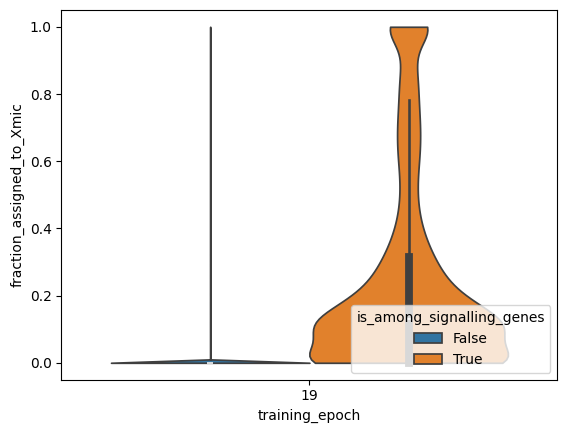

In [10]:
sns.violinplot(
    data=df_toinspect[
        df_toinspect['read_count'] > 30.0
    ],
    x='training_epoch',
    y="fraction_assigned_to_Xmic",
    hue="is_among_signalling_genes",
    cut=0
)

2026-01-15 15:06:21 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-01-15 15:06:21 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


<Axes: xlabel='training_epoch', ylabel='fraction_assigned_to_Xmic'>

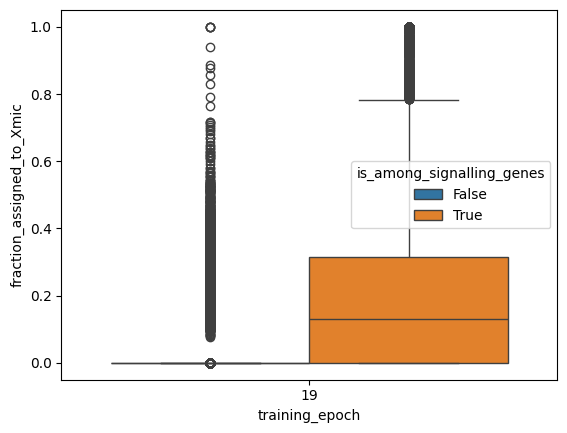

In [11]:
sns.boxplot(
    data=df_toinspect[
        df_toinspect['read_count'] > 30.0
    ],
    x='training_epoch',
    y="fraction_assigned_to_Xmic",
    hue="is_among_signalling_genes"
)

## Load the predictions checkpoint

In [12]:
index_selected_checkpoint = 19
# TODO:MODIFY: the index of the best (or a good) checkpoint that you selected. 

In [13]:
with open(os.path.join(path_output_files, "predictions_epoch_{}.pkl".format(index_selected_checkpoint)), 'rb') as f:
    predictions_selected_checkpoint = pickle.load(f)

## Load adata and compute microenvironment activity score

In [14]:
Xint = predictions_selected_checkpoint['TissueSection 0 (zero-based)']['MintFlow_Xint']
Xmic = predictions_selected_checkpoint['TissueSection 0 (zero-based)']['MintFlow_Xmic']

In [15]:
MintFlow_microenvironment_signalling_score = Xmic.sum(1) / (Xint+Xmic).sum(1)

In [16]:
MintFlow_microenvironment_signalling_score

matrix([[0.5029946 ],
        [0.47170073],
        [0.5725127 ],
        ...,
        [0.5257381 ],
        [0.55768406],
        [0.5247529 ]], shape=(252242, 1), dtype=float32)

In [17]:
adata = sc.read_h5ad(
    path_adata
)

In [18]:
adata.obs["MintFlow_microenv_score"] = MintFlow_microenvironment_signalling_score

In [19]:
adata.obs

,tissue,X,Y,DeconvolutionClass,DeconvolutionLabel1,DeconvolutionLabel2,Periphery,UnsupervisedL1,UnsupervisedL2,MacrophageSubtype,GobletSubcluster,patient,patient_id,MintFlow_microenv_score
s_008um_00602_00290-1,1,434.803906,-381.983277,singlet,vSM,Unknown III (SM),Tissue,Smooth Muscle,SmoothMuscle-2,NaN,NaN,P5,P5,0.502995
s_008um_00128_00278-1,1,431.447280,-495.967791,singlet,Tumor IV,Tumor V,Tumor,Tumor,Tumor-1,NaN,NaN,P5,P5,0.471701
s_008um_00052_00559-1,1,498.955590,-514.524988,singlet,Neutrophil,Vascular Fibroblast,Tissue,Myeloid,Myeloid-1,NaN,NaN,P5,P5,0.572513
s_008um_00504_00410-1,1,463.567006,-405.670057,singlet,Plasma,Enteric Glial,Tissue,B cells,Bcells-0,NaN,NaN,P5,P5,0.344039
s_008um_00447_00253-1,1,425.751446,-419.223234,singlet,Tumor IV,Tumor II,Tumor,Unknown,Unknown-0,NaN,NaN,P5,P5,0.432259
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
s_008um_00821_00426-1,1,467.729054,-329.450389,singlet,vSM,Smooth Muscle,Tissue,Smooth Muscle,SmoothMuscle-0,NaN,NaN,P5,P5,0.482270
s_008um_00197_00639-1,1,518.339915,-479.730417,singlet,Goblet,Tumor III,Tissue,Intestinal Epithelial,IntestinalEpithelial-0,NaN,Goblet-0,P5,P5,0.246754
s_008um_00653_00166-1,1,405.032707,-369.595995,singlet,CD4 T cell,Proliferating Immune II,Tissue,T cells,Tcells-0,NaN,NaN,P5,P5,0.525738
s_008um_00353_00477-1,1,479.531390,-442.051476,singlet,Fibroblast,Proliferating Fibroblast,Tissue,Fibroblast,Fibroblast-0,NaN,NaN,P5,P5,0.557684


## Load Mintflow model checkpoint

In [20]:
path_checkpoint = '/nfs/team361/ms83/data/CRC/visiumHD_mintflow/Outputs_nb1_P5_annealing/checkpoint_epoch_19.pt'  

In [21]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(device)

cuda:0


In [22]:
checkpoint_mintflow = torch.load(
    path_checkpoint,
    map_location='cpu',
    weights_only=False
)
checkpoint_mintflow['model'].to(device)
print("Loaded the checkpoint.")

Loaded the checkpoint.


In [23]:
import pickle
with open('/nfs/team361/ms83/data/CRC/visiumHD_mintflow/Outputs_nb1_P5_annealing/predictions_epoch_19.pkl', 'rb') as f:
   dict_predictions = pickle.load(f)

In [24]:
dict_predictions.keys()

dict_keys(['TissueSection 0 (zero-based)'])

In [25]:
dict_predictions['TissueSection 0 (zero-based)']

{'MintFlow_Xint': <Compressed Sparse Row sparse matrix of dtype 'float32'
 	with 32795035 stored elements and shape (252242, 7000)>,
 'MintFlow_Xmic': <Compressed Sparse Row sparse matrix of dtype 'float32'
 	with 71002716 stored elements and shape (252242, 7000)>,
 'MintFlow_Xbar_int': array([[0.7703979 , 0.81066835, 0.51108223, ..., 0.760943  , 0.7135202 ,
         0.50192237],
        [0.76093686, 0.8059445 , 0.48522428, ..., 0.752269  , 0.70477855,
         0.49976894],
        [0.7595352 , 0.79841256, 0.5138657 , ..., 0.7465646 , 0.7034919 ,
         0.5133669 ],
        ...,
        [0.7720069 , 0.7998533 , 0.5080525 , ..., 0.76619446, 0.72532785,
         0.49428275],
        [0.7592052 , 0.79937065, 0.5175933 , ..., 0.763319  , 0.72959423,
         0.47967815],
        [0.77129436, 0.805031  , 0.5214193 , ..., 0.7721107 , 0.7406359 ,
         0.51140124]], shape=(252242, 100), dtype=float32),
 'MintFlow_Xbar_mic': array([[0.36491024, 0.19682439, 0.7040126 , ..., 0.        , 0.6

In [26]:
checkpoint_mintflow.keys()

dict_keys(['model', 'data_mintflow', 'dict_all4_configs'])

In [27]:
checkpoint_mintflow['data_mintflow']

{'train_list_tissue_section': <mintflow.utils_multislice.ListSlice at 0x147a32073190>,
 'evaluation_list_tissue_section': <mintflow.utils_multislice.ListSlice at 0x147a321b5890>,
 'maxsize_subgraph': 11698,
 'dict_slideID_to_maxnumcentralnodes': {'1': 1948.0},
 'dict_slideID_to_worsecasebatchsize': {'1': 11698},
 'dict_sliceID_to_pygdltrain_num_neighbours': {'1': [5]}}

In [28]:
checkpoint_mintflow['data_mintflow']['train_list_tissue_section'].list_slice[0].adata

AnnData object with n_obs × n_vars = 252242 × 7000
    obs: 'tissue', 'X', 'Y', 'DeconvolutionClass', 'DeconvolutionLabel1', 'DeconvolutionLabel2', 'Periphery', 'UnsupervisedL1', 'UnsupervisedL2', 'MacrophageSubtype', 'GobletSubcluster', 'patient', 'patient_id', 'inflow_CT', 'inflow_BatchID'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'DeconvolutionLabel2_centrality_scores', 'DeconvolutionLabel2_colors', 'DeconvolutionLabel2_nhood_enrichment', 'log1p', 'neighbors', 'pca', 'spatial', 'spatial_neighbors', 'umap', 'inflow_CT_colors'
    obsm: 'X_pca', 'X_umap', 'spatial'
    obsp: 'spatial_connectivities', 'spatial_distances'

In [29]:
adata = checkpoint_mintflow['data_mintflow']['train_list_tissue_section'].list_slice[0].adata.copy()

In [30]:
dict_predictions['TissueSection 0 (zero-based)'].keys()

dict_keys(['MintFlow_Xint', 'MintFlow_Xmic', 'MintFlow_Xbar_int', 'MintFlow_Xbar_mic', 'MintFlow_S_in', 'MintFlow_S_out', 'MintFlow_Z', 'MintFlow_Xint (before_sc_pp_normalize_total)', 'MintFlow_Xmic (before_sc_pp_normalize_total)'])

In [31]:
for k in dict_predictions['TissueSection 0 (zero-based)'].keys():
    adata.obsm[k] = dict_predictions['TissueSection 0 (zero-based)'][k]

In [32]:
adata

AnnData object with n_obs × n_vars = 252242 × 7000
    obs: 'tissue', 'X', 'Y', 'DeconvolutionClass', 'DeconvolutionLabel1', 'DeconvolutionLabel2', 'Periphery', 'UnsupervisedL1', 'UnsupervisedL2', 'MacrophageSubtype', 'GobletSubcluster', 'patient', 'patient_id', 'inflow_CT', 'inflow_BatchID'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'DeconvolutionLabel2_centrality_scores', 'DeconvolutionLabel2_colors', 'DeconvolutionLabel2_nhood_enrichment', 'log1p', 'neighbors', 'pca', 'spatial', 'spatial_neighbors', 'umap', 'inflow_CT_colors'
    obsm: 'X_pca', 'X_umap', 'spatial', 'MintFlow_Xint', 'MintFlow_Xmic', 'MintFlow_Xbar_int', 'MintFlow_Xbar_mic', 'MintFlow_S_in', 'MintFlow_S_out', 'MintFlow_Z', 'MintFlow_Xint (before_sc_pp_normalize_total)', 'MintFlow_Xmic (before_sc_pp_normalize_total)'
    obsp: 'spatial_connectivities', 'spatial_distances'

## Perform PCA, nearest neighbors and UMAP based on X bar intrinsic

In [33]:
pca = PCA(n_components=50, svd_solver="arpack")
X_pca_barint = pca.fit_transform(adata.obsm["MintFlow_Xbar_int"])

adata.obsm["X_PCA_barint"] = X_pca_barint
adata.uns["X_PCA_barint"] = {
    'variance': pca.explained_variance_,
    'variance_ratio': pca.explained_variance_ratio_
}

rsc.pp.neighbors(adata, use_rep="X_PCA_barint", key_added="neighbors_barint")
rsc.tl.umap(adata, neighbors_key="neighbors_barint", key_added="X_UMAP_barint")

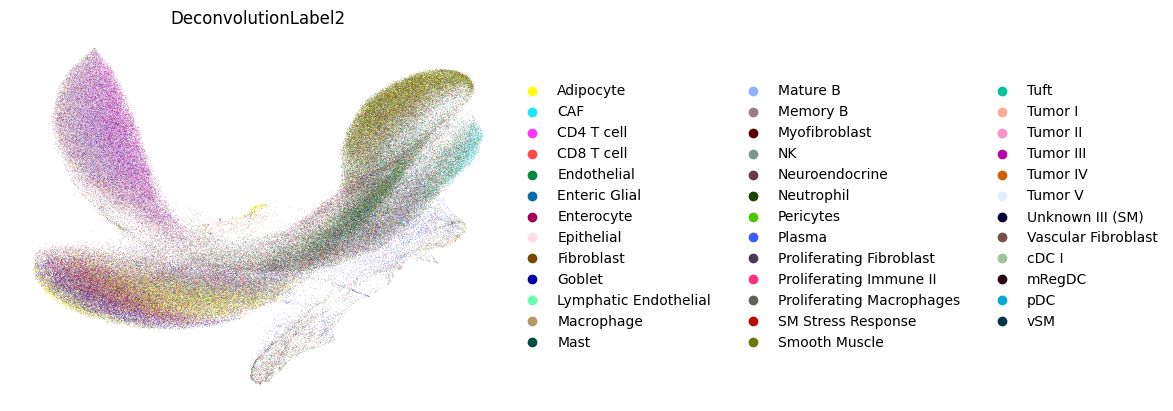

In [34]:
sc.pl.embedding(
    adata,
    color='DeconvolutionLabel2',
    basis="X_UMAP_barint",
    frameon=False
)

## Perform PCA, nearest neighbors and UMAP based on X bar spatial

In [35]:
pca = PCA(n_components=50, svd_solver="arpack")
X_pca_barint = pca.fit_transform(adata.obsm["MintFlow_Xbar_mic"])

adata.obsm["X_PCA_barmic"] = X_pca_barint
adata.uns["X_PCA_barmic"] = {
    'variance': pca.explained_variance_,
    'variance_ratio': pca.explained_variance_ratio_
}

rsc.pp.neighbors(adata, use_rep="X_PCA_barmic", key_added="neighbors_barmic")
rsc.tl.umap(adata, neighbors_key="neighbors_barmic", key_added="X_UMAP_barmic")

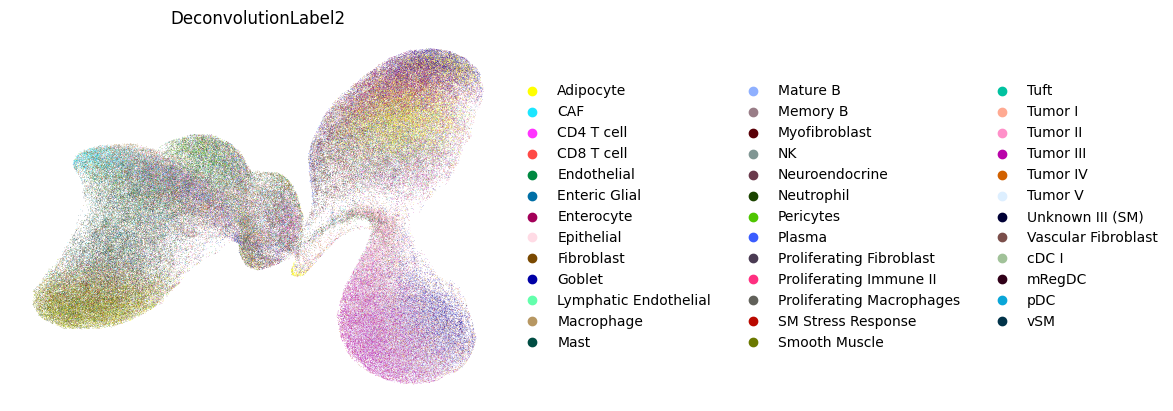

In [36]:
sc.pl.embedding(
    adata,
    color='DeconvolutionLabel2',
    basis="X_UMAP_barmic",
    frameon=False
)

## Perform PCA, nearest neighbors and UMAP based on X intrinsic

In [37]:
pca = PCA(n_components=50, svd_solver="arpack")
X_pca_barint = pca.fit_transform(adata.obsm["MintFlow_Xint"])

adata.obsm["X_PCA_int"] = X_pca_barint
adata.uns["X_PCA_int"] = {
    'variance': pca.explained_variance_,
    'variance_ratio': pca.explained_variance_ratio_
}

rsc.pp.neighbors(adata, use_rep="X_PCA_int", key_added="neighbors_int")
rsc.tl.umap(adata, neighbors_key="neighbors_int", key_added="X_UMAP_int")

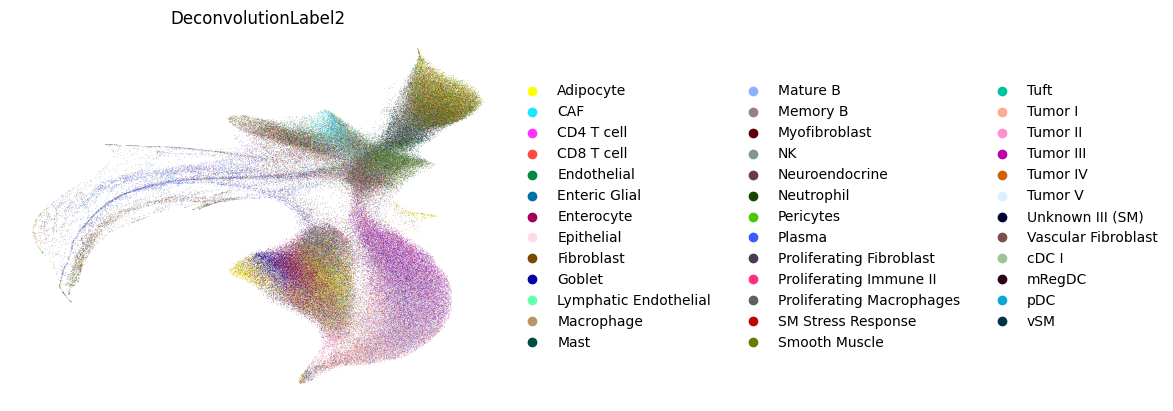

In [38]:
sc.pl.embedding(
    adata,
    color='DeconvolutionLabel2',
    basis="X_UMAP_int",
    frameon=False
)

## Perform PCA, nearest neighbors and UMAP based on X spatial

In [39]:
pca = PCA(n_components=50, svd_solver="arpack")
X_pca_barint = pca.fit_transform(adata.obsm["MintFlow_Xmic"])

adata.obsm["X_PCA_mic"] = X_pca_barint
adata.uns["X_PCA_mic"] = {
    'variance': pca.explained_variance_,
    'variance_ratio': pca.explained_variance_ratio_
}

rsc.pp.neighbors(adata, use_rep="X_PCA_mic", key_added="neighbors_mic")
rsc.tl.umap(adata, neighbors_key="neighbors_mic", key_added="X_UMAP_mic")

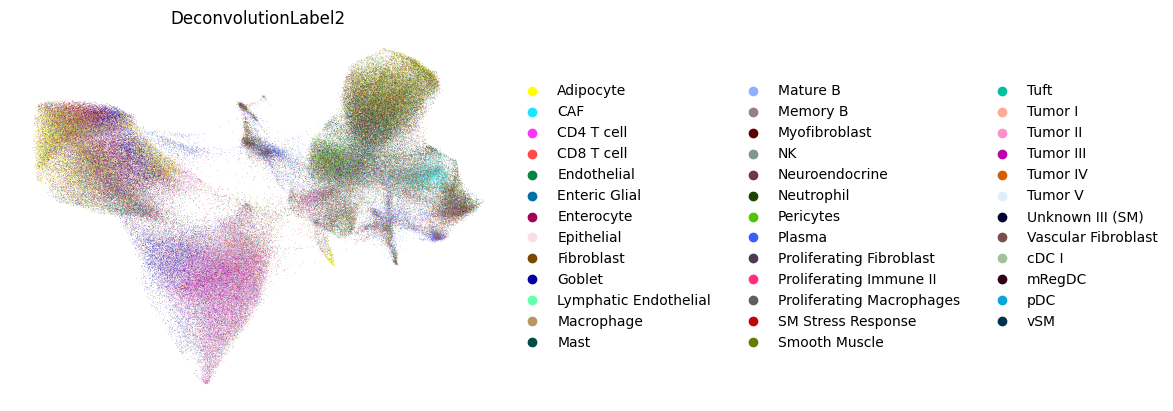

In [40]:
sc.pl.embedding(
    adata,
    color='DeconvolutionLabel2',
    basis="X_UMAP_mic",
    frameon=False
)

In [48]:
tls_signature_minimal = [
    'CXCL13',  # Most specific TLS marker
    'MS4A1',   # CD20, B cells
    'CD3D',    # T cells
    'CD79A',   # B cells
    'CCL21',   # TLS chemokine
    'BCL6',    # Germinal centers
    'CXCR5'    # Follicular helper T cells
]

In [49]:
sc.tl.score_genes(adata, 
    tls_signature_minimal, 
    score_name = "TLS_general", use_raw=True)

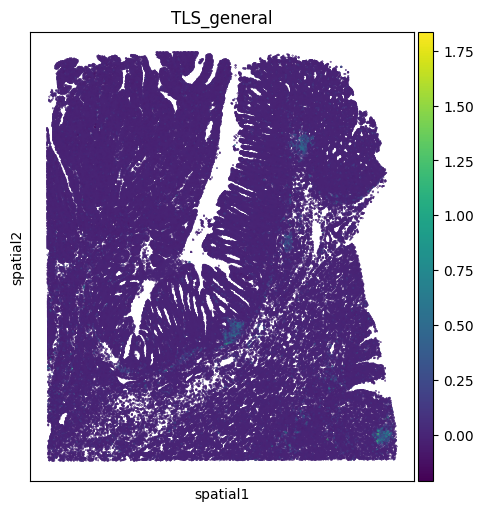

In [50]:
sq.pl.spatial_scatter(
    adata,
    library_id="spatial",
    shape=None,
    color=["TLS_general"],
    #groups=["CD8 T cell"],   # cell type(s) of interest
    wspace=0.4,
    size=0.2,
    figsize=(5, 5)
)

In [51]:
adata.obs["MintFlow_microenv_score"] = MintFlow_microenvironment_signalling_score

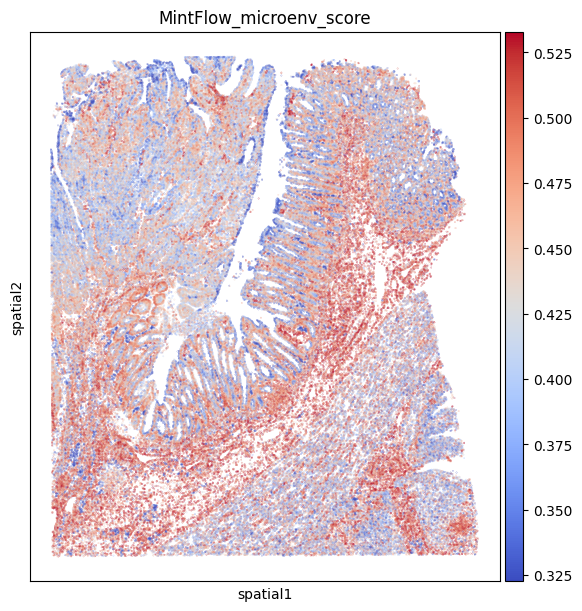

In [52]:
sq.pl.spatial_scatter(
    adata,
    library_id="spatial",
    shape=None,
    color=[
        "MintFlow_microenv_score",    
    ],
    cmap='coolwarm',
    wspace=0.4,
    size=0.02,
    figsize=(6, 6),
    vmin=np.percentile(adata.obs['MintFlow_microenv_score'], 5),
    vmax=np.percentile(adata.obs['MintFlow_microenv_score'], 95)
)

In [53]:
adata

AnnData object with n_obs × n_vars = 252242 × 7000
    obs: 'tissue', 'X', 'Y', 'DeconvolutionClass', 'DeconvolutionLabel1', 'DeconvolutionLabel2', 'Periphery', 'UnsupervisedL1', 'UnsupervisedL2', 'MacrophageSubtype', 'GobletSubcluster', 'patient', 'patient_id', 'inflow_CT', 'inflow_BatchID', 'TLS_general', 'MintFlow_microenv_score'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'DeconvolutionLabel2_centrality_scores', 'DeconvolutionLabel2_colors', 'DeconvolutionLabel2_nhood_enrichment', 'log1p', 'neighbors', 'pca', 'spatial', 'spatial_neighbors', 'umap', 'inflow_CT_colors', 'X_PCA_barint', 'neighbors_barint', 'X_UMAP_barint', 'X_PCA_barmic', 'neighbors_barmic', 'X_UMAP_barmic', 'X_PCA_int', 'neighbors_int', 'X_UMAP_int', 'X_PCA_mic', 'neighbors_mic', 'X_UMAP_mic'
    obsm: 'X_pca', 'X_umap', 'spatial', 'MintFlow_Xint', 'MintFlow_Xmic', 'MintFlow_Xbar_int', 'MintFlow_Xbar_mic', 'MintFlow_S_in', 'MintFlow_S_out', 'MintFlow_Z', 'MintFlow_Xint (before_sc_pp_normalize_total)', 'Mi

In [55]:
sc.tl.leiden(adata, 
             flavor="igraph", 
             n_iterations=2,
             neighbors_key="neighbors_int", 
             key_added="leiden_int"
            )

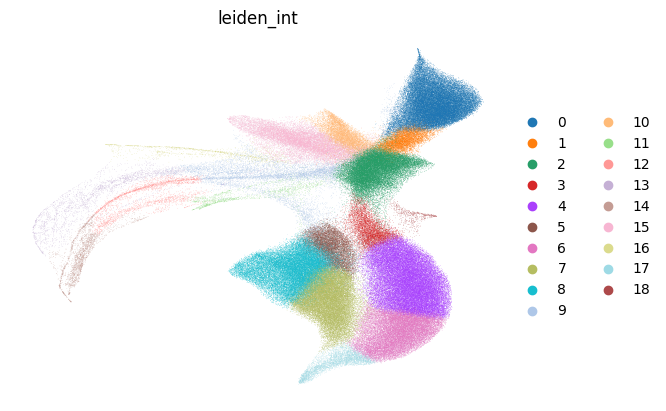

In [56]:
sc.pl.embedding(
    adata,
    color='leiden_int',
    basis="X_UMAP_int",
    frameon=False
)

/software/cellgen/team361/ms83/envs/env_Dec11th_mintflowandrapids/lib/python3.11/site-packages/squidpy/pl/_spatial_utils.py:982: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(


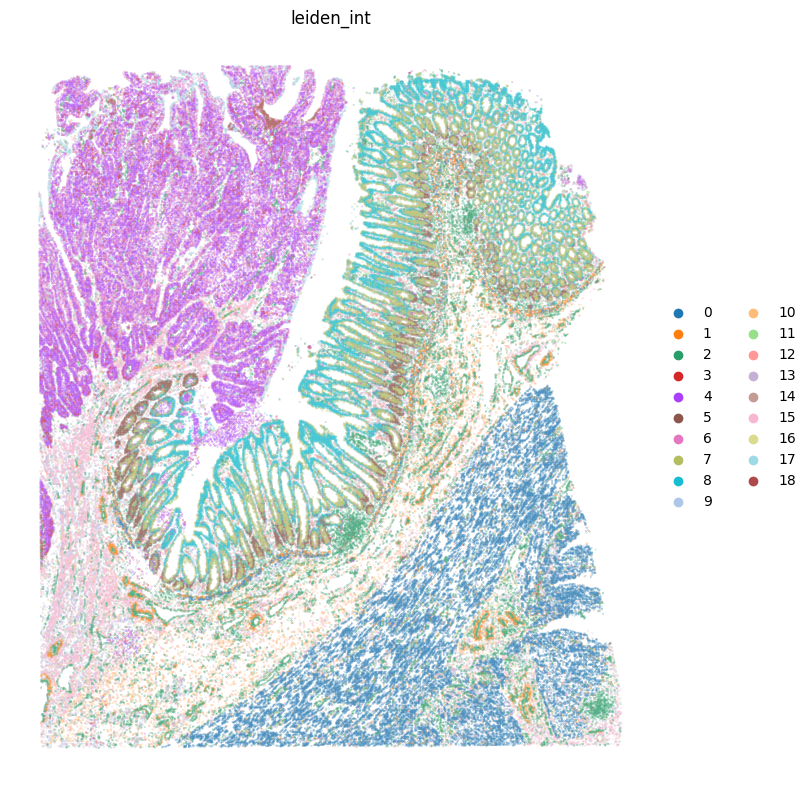

In [67]:
sq.pl.spatial_scatter(
    adata,
    library_id="spatial",
    shape=None,
    color=[
        "leiden_int",
    ],
    wspace=0.4,
    size=0.02,
    figsize=(8, 8),
    frameon=False
)

In [59]:
sc.tl.leiden(adata, 
             flavor="igraph", 
             n_iterations=2,
             neighbors_key="neighbors_mic", 
             key_added="leiden_mic"
            )

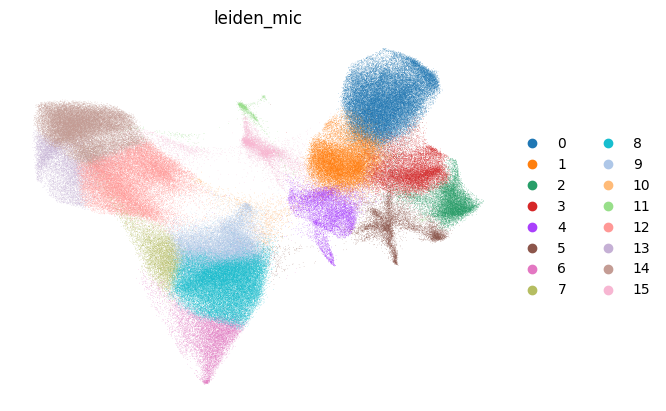

In [60]:
sc.pl.embedding(
    adata,
    color='leiden_mic',
    basis="X_UMAP_mic",
    frameon=False
)

/software/cellgen/team361/ms83/envs/env_Dec11th_mintflowandrapids/lib/python3.11/site-packages/squidpy/pl/_spatial_utils.py:982: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(


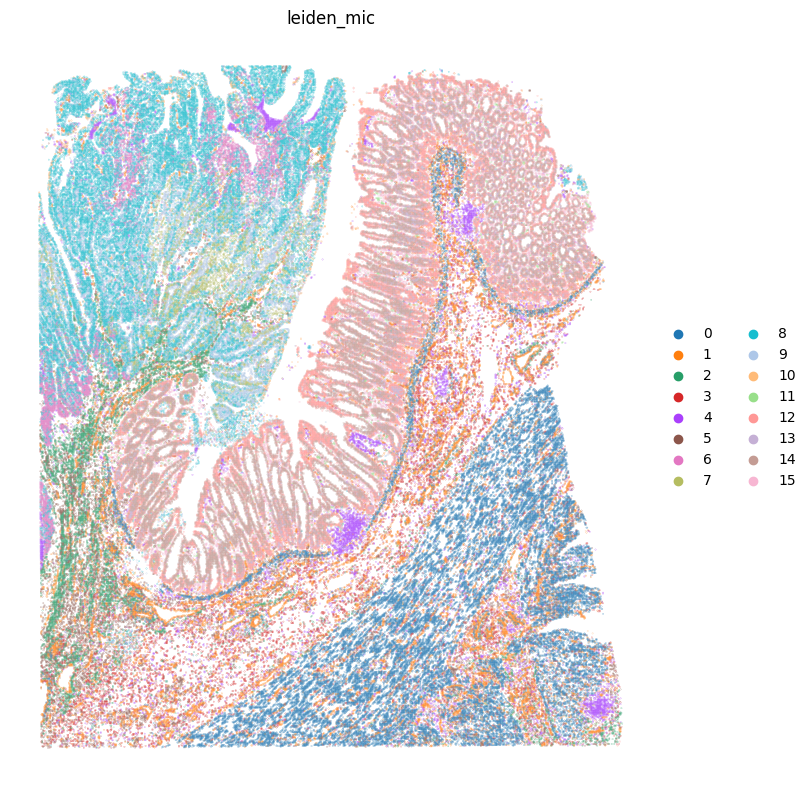

In [66]:
sq.pl.spatial_scatter(
    adata,
    library_id="spatial",
    shape=None,
    color=[
        "leiden_mic",
    ],
    wspace=0.4,
    size=0.02,
    figsize=(8, 8),
    frameon=False
)

In [62]:
adata.write_h5ad(path_output_files + 'adata_P5_mic_score.h5ad')

In [75]:
df_1 = pd.crosstab(adata.obs['DeconvolutionLabel2'], adata.obs['leiden_mic'])
df_1

leiden_mic,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
DeconvolutionLabel2,,,,,,,,,,,,,,,,
Adipocyte,4265,945,214,361,568,204,13,11,28,77,140,56,4707,2782,7003,187
CAF,1320,1143,789,3241,472,513,24,4,47,112,29,24,223,47,291,118
CD4 T cell,424,592,551,457,765,265,14,9,77,85,32,61,534,67,368,249
CD8 T cell,904,702,558,557,557,282,17,15,59,74,48,40,1098,154,684,262
Endothelial,1018,1488,419,369,292,267,14,8,105,118,21,43,267,64,313,229
Enteric Glial,843,647,142,418,213,100,8,2,14,40,13,23,316,81,294,157
Enterocyte,170,120,33,54,90,12,86,30,160,116,57,27,2963,1446,7183,158
Epithelial,1,15,3,0,4,1,0,0,0,1,1,2,4,2,1,32
Fibroblast,937,1587,1643,1807,1570,697,18,10,33,76,34,135,415,59,286,698


In [83]:
adata.uns.keys()

dict_keys(['DeconvolutionLabel2_centrality_scores', 'DeconvolutionLabel2_colors', 'DeconvolutionLabel2_nhood_enrichment', 'log1p', 'neighbors', 'pca', 'spatial', 'spatial_neighbors', 'umap', 'inflow_CT_colors', 'X_PCA_barint', 'neighbors_barint', 'X_UMAP_barint', 'X_PCA_barmic', 'neighbors_barmic', 'X_UMAP_barmic', 'X_PCA_int', 'neighbors_int', 'X_UMAP_int', 'X_PCA_mic', 'neighbors_mic', 'X_UMAP_mic', 'leiden_int', 'leiden_int_colors', 'leiden_mic', 'leiden_mic_colors'])

/tmp/ipykernel_2411539/1540900095.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cluster_composition = adata.obs.groupby(['leiden_mic', 'DeconvolutionLabel2']).size().unstack(fill_value=0)


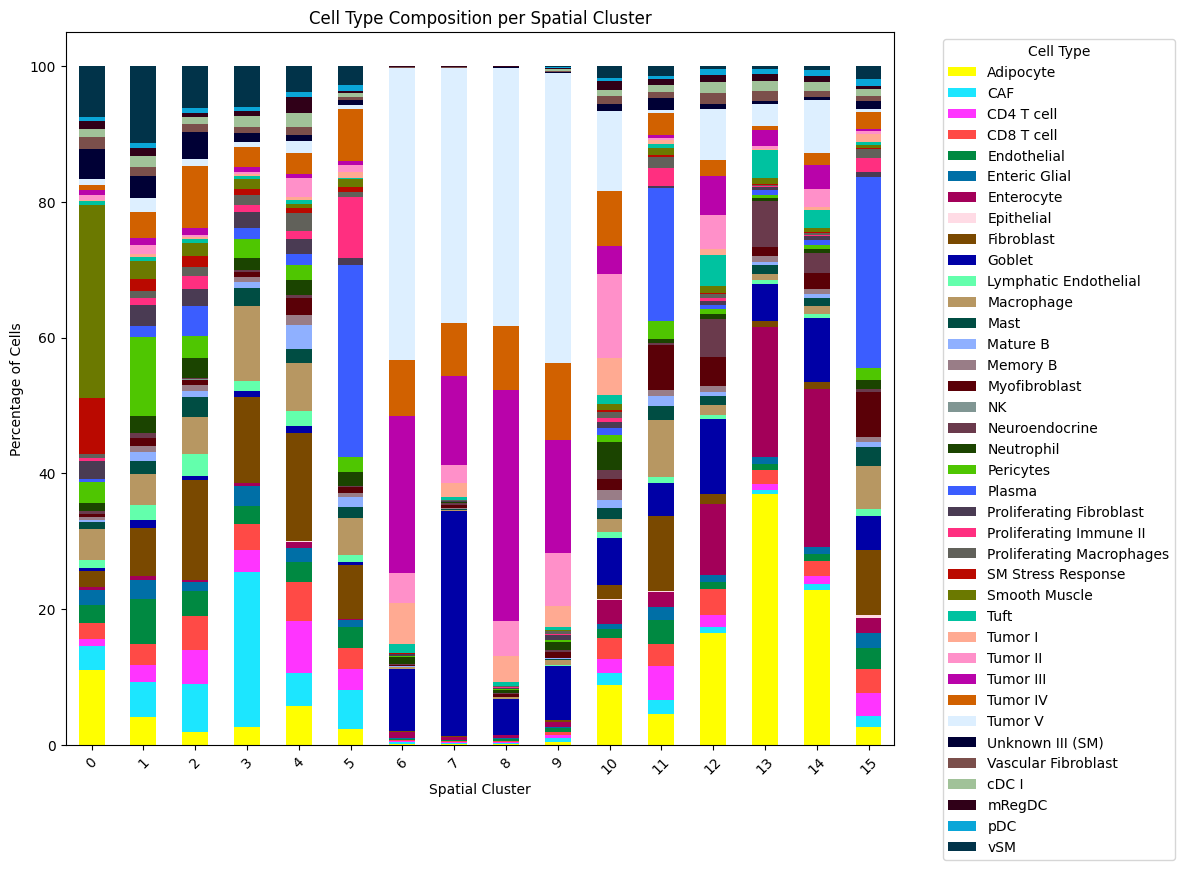

In [91]:
# Group by leiden clusters and cell types, then count occurrences
cluster_composition = adata.obs.groupby(['leiden_mic', 'DeconvolutionLabel2']).size().unstack(fill_value=0)

# Normalize to get percentages
cluster_composition_percentage = cluster_composition.div(cluster_composition.sum(axis=1), axis=0) * 100

# Use Scanpy's default categorical palette (the same used in sc.pl.umap)
n_colors = len(cluster_composition.columns)
if n_colors <= 28:
    custom_palette = sc.pl.palettes.default_28
elif n_colors <= 102:
    custom_palette = sc.pl.palettes.default_102[:n_colors]
else:
    # Fallback for more than 102 categories
    custom_palette = sc.pl.palettes.default_102 + sns.color_palette("husl", n_colors - 102)

# Plot stacked bar chart
ax = cluster_composition_percentage.plot(kind='bar', stacked=True, figsize=(12, 9), color=custom_palette)
ax.grid(False)
plt.xlabel("Spatial Cluster")
plt.ylabel("Percentage of Cells")
plt.title("Cell Type Composition per Spatial Cluster")
plt.legend(title="Cell Type", bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

/tmp/ipykernel_2411539/1948652509.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cluster_composition = adata.obs.groupby(['leiden_int', 'DeconvolutionLabel2']).size().unstack(fill_value=0)


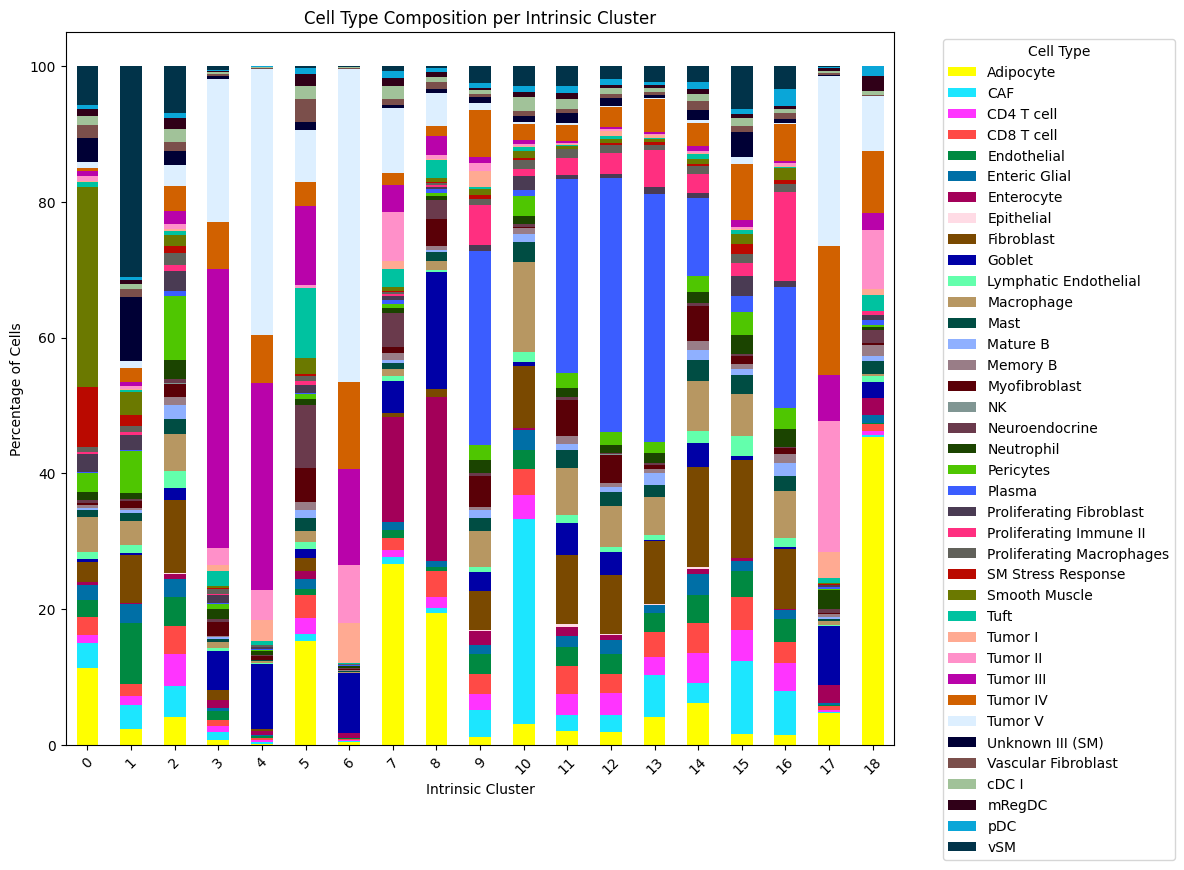

In [92]:
# Group by leiden clusters and cell types, then count occurrences
cluster_composition = adata.obs.groupby(['leiden_int', 'DeconvolutionLabel2']).size().unstack(fill_value=0)

# Normalize to get percentages
cluster_composition_percentage = cluster_composition.div(cluster_composition.sum(axis=1), axis=0) * 100

# Use Scanpy's default categorical palette (the same used in sc.pl.umap)
n_colors = len(cluster_composition.columns)
if n_colors <= 28:
    custom_palette = sc.pl.palettes.default_28
elif n_colors <= 102:
    custom_palette = sc.pl.palettes.default_102[:n_colors]
else:
    # Fallback for more than 102 categories
    custom_palette = sc.pl.palettes.default_102 + sns.color_palette("husl", n_colors - 102)

# Plot stacked bar chart
ax = cluster_composition_percentage.plot(kind='bar', stacked=True, figsize=(12, 9), color=custom_palette)
ax.grid(False)
plt.xlabel("Intrinsic Cluster")
plt.ylabel("Percentage of Cells")
plt.title("Cell Type Composition per Intrinsic Cluster")
plt.legend(title="Cell Type", bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Run T cells analysis on spatial domains

In [68]:
adata_Tcell = adata[(adata.obs['DeconvolutionLabel2'] == 'CD4 T cell') |
                    (adata.obs['DeconvolutionLabel2'] == 'CD8 T cell')].copy() # Subset the AnnData object
print(adata_Tcell)

AnnData object with n_obs × n_vars = 10561 × 7000
    obs: 'tissue', 'X', 'Y', 'DeconvolutionClass', 'DeconvolutionLabel1', 'DeconvolutionLabel2', 'Periphery', 'UnsupervisedL1', 'UnsupervisedL2', 'MacrophageSubtype', 'GobletSubcluster', 'patient', 'patient_id', 'inflow_CT', 'inflow_BatchID', 'TLS_general', 'MintFlow_microenv_score', 'leiden_int', 'leiden_mic'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'DeconvolutionLabel2_centrality_scores', 'DeconvolutionLabel2_colors', 'DeconvolutionLabel2_nhood_enrichment', 'log1p', 'neighbors', 'pca', 'spatial', 'spatial_neighbors', 'umap', 'inflow_CT_colors', 'X_PCA_barint', 'neighbors_barint', 'X_UMAP_barint', 'X_PCA_barmic', 'neighbors_barmic', 'X_UMAP_barmic', 'X_PCA_int', 'neighbors_int', 'X_UMAP_int', 'X_PCA_mic', 'neighbors_mic', 'X_UMAP_mic', 'leiden_int', 'leiden_int_colors', 'leiden_mic', 'leiden_mic_colors'
    obsm: 'X_pca', 'X_umap', 'spatial', 'MintFlow_Xint', 'MintFlow_Xmic', 'MintFlow_Xbar_int', 'MintFlow_Xbar_mic', 'Mi

/software/cellgen/team361/ms83/envs/env_Dec11th_mintflowandrapids/lib/python3.11/site-packages/squidpy/pl/_spatial_utils.py:982: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(


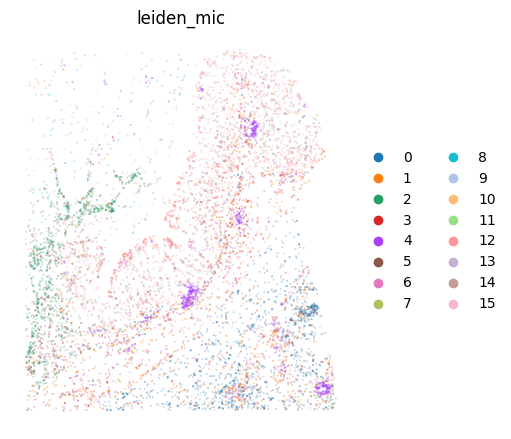

In [77]:
sq.pl.spatial_scatter(
    adata_Tcell,
    library_id="spatial",
    shape=None,
    color=[
        "leiden_mic",
    ],
    wspace=0.4,
    size=0.02,
    figsize=(5, 5),
    frameon=False
)

/software/cellgen/team361/ms83/envs/env_Dec11th_mintflowandrapids/lib/python3.11/site-packages/squidpy/pl/_spatial_utils.py:982: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(


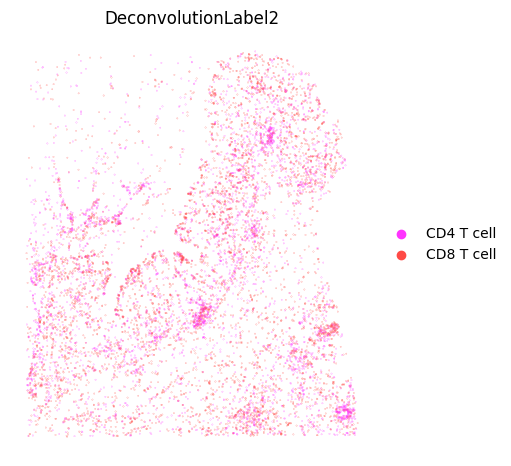

In [90]:
sq.pl.spatial_scatter(
    adata_Tcell,
    library_id="spatial",
    shape=None,
    color=[
        "DeconvolutionLabel2",
    ],
    wspace=0.4,
    size=0.02,
    figsize=(5, 5),
    frameon=False
)

/software/cellgen/team361/ms83/envs/env_Dec11th_mintflowandrapids/lib/python3.11/site-packages/squidpy/pl/_spatial_utils.py:982: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(


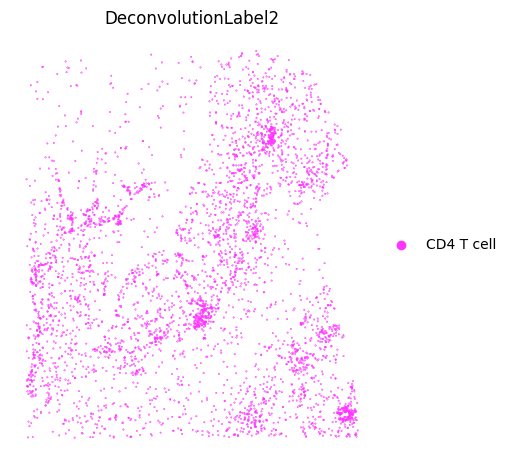

In [93]:
sq.pl.spatial_scatter(
    adata_Tcell,
    library_id="spatial",
    shape=None,
    color="DeconvolutionLabel2",
    groups=["CD4 T cell"],   # cell type(s) of interest
    wspace=0.4,
    size=0.2,
    figsize=(5, 5),
    frameon=False
)

/software/cellgen/team361/ms83/envs/env_Dec11th_mintflowandrapids/lib/python3.11/site-packages/squidpy/pl/_spatial_utils.py:982: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(


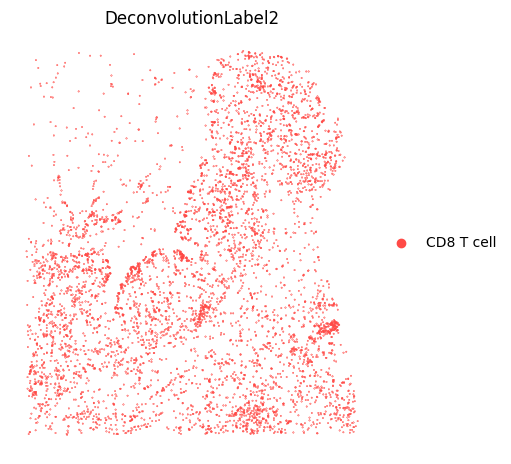

In [94]:
sq.pl.spatial_scatter(
    adata_Tcell,
    library_id="spatial",
    shape=None,
    color="DeconvolutionLabel2",
    groups=["CD8 T cell"],   # cell type(s) of interest
    wspace=0.4,
    size=0.2,
    figsize=(5, 5),
    frameon=False
)

In [69]:
pca = PCA(n_components=50, svd_solver="arpack")
X_pca_mic = pca.fit_transform(adata_Tcell.obsm["MintFlow_Xmic"])

adata_Tcell.obsm["X_PCA_mic"] = X_pca_mic
adata_Tcell.uns["X_PCA_mic"] = {
    'variance': pca.explained_variance_,
    'variance_ratio': pca.explained_variance_ratio_
}

rsc.pp.neighbors(adata_Tcell, use_rep="X_PCA_mic", key_added="neighbors_mic")
rsc.tl.umap(adata_Tcell, neighbors_key="neighbors_mic", key_added="X_UMAP_mic")

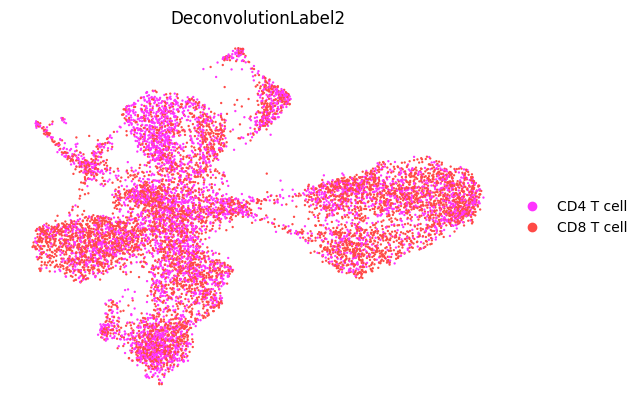

In [70]:
sc.pl.embedding(
    adata_Tcell,
    color='DeconvolutionLabel2',
    basis="X_UMAP_mic",
    frameon=False
)

In [71]:
pca = PCA(n_components=50, svd_solver="arpack")
X_pca_int = pca.fit_transform(adata_Tcell.obsm["MintFlow_Xint"])

adata_Tcell.obsm["X_PCA_int"] = X_pca_int
adata_Tcell.uns["X_PCA_int"] = {
    'variance': pca.explained_variance_,
    'variance_ratio': pca.explained_variance_ratio_
}

rsc.pp.neighbors(adata_Tcell, use_rep="X_PCA_int", key_added="neighbors_int")
rsc.tl.umap(adata_Tcell, neighbors_key="neighbors_int", key_added="X_UMAP_int")

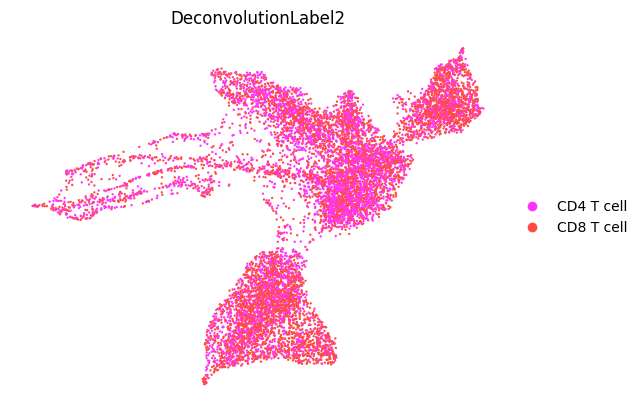

In [72]:
sc.pl.embedding(
    adata_Tcell,
    color='DeconvolutionLabel2',
    basis="X_UMAP_int",
    frameon=False
)

## Run immune cells analysis on spatial domains

In [95]:
adata.obs['DeconvolutionLabel2'].value_counts()

DeconvolutionLabel2
Tumor V                      34206
Tumor III                    21921
Adipocyte                    21561
Goblet                       14185
Smooth Muscle                12735
Enterocyte                   12705
Tumor IV                     11932
Fibroblast                   10005
CAF                           8397
vSM                           8239
Macrophage                    7885
Tumor II                      7497
Plasma                        6731
CD8 T cell                    6011
Pericytes                     5728
Endothelial                   5035
CD4 T cell                    4550
SM Stress Response            4243
Myofibroblast                 3909
Unknown III (SM)              3795
Neuroendocrine                3652
Tumor I                       3513
Tuft                          3512
Proliferating Fibroblast      3321
Enteric Glial                 3311
Neutrophil                    3124
Mast                          3032
cDC I                         2567


In [97]:
adata_immune = adata[(adata.obs['DeconvolutionLabel2'] == 'CD4 T cell') |
                    (adata.obs['DeconvolutionLabel2'] == 'CD8 T cell') |
                    (adata.obs['DeconvolutionLabel2'] == 'Mature B') |
                    (adata.obs['DeconvolutionLabel2'] == 'Memory B') |
                    (adata.obs['DeconvolutionLabel2'] == 'Macrophage') |
                    (adata.obs['DeconvolutionLabel2'] == 'cDC I') |
                    (adata.obs['DeconvolutionLabel2'] == 'pDC') |
                    (adata.obs['DeconvolutionLabel2'] == 'mRegDC')].copy()# Subset the AnnData object
print(adata_immune)

AnnData object with n_obs × n_vars = 27399 × 7000
    obs: 'tissue', 'X', 'Y', 'DeconvolutionClass', 'DeconvolutionLabel1', 'DeconvolutionLabel2', 'Periphery', 'UnsupervisedL1', 'UnsupervisedL2', 'MacrophageSubtype', 'GobletSubcluster', 'patient', 'patient_id', 'inflow_CT', 'inflow_BatchID', 'TLS_general', 'MintFlow_microenv_score', 'leiden_int', 'leiden_mic'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'DeconvolutionLabel2_centrality_scores', 'DeconvolutionLabel2_colors', 'DeconvolutionLabel2_nhood_enrichment', 'log1p', 'neighbors', 'pca', 'spatial', 'spatial_neighbors', 'umap', 'inflow_CT_colors', 'X_PCA_barint', 'neighbors_barint', 'X_UMAP_barint', 'X_PCA_barmic', 'neighbors_barmic', 'X_UMAP_barmic', 'X_PCA_int', 'neighbors_int', 'X_UMAP_int', 'X_PCA_mic', 'neighbors_mic', 'X_UMAP_mic', 'leiden_int', 'leiden_int_colors', 'leiden_mic', 'leiden_mic_colors'
    obsm: 'X_pca', 'X_umap', 'spatial', 'MintFlow_Xint', 'MintFlow_Xmic', 'MintFlow_Xbar_int', 'MintFlow_Xbar_mic', 'Mi

/software/cellgen/team361/ms83/envs/env_Dec11th_mintflowandrapids/lib/python3.11/site-packages/squidpy/pl/_spatial_utils.py:982: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(


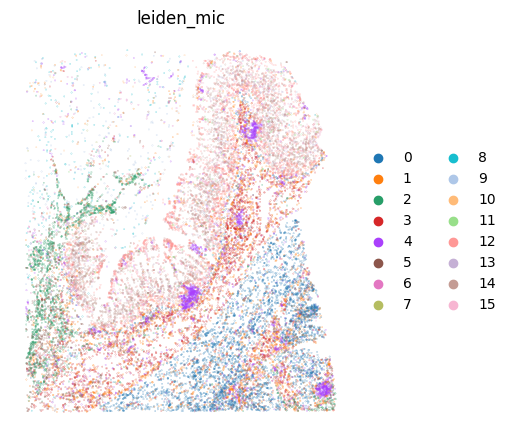

In [98]:
sq.pl.spatial_scatter(
    adata_immune,
    library_id="spatial",
    shape=None,
    color=[
        "leiden_mic",
    ],
    wspace=0.4,
    size=0.02,
    figsize=(5, 5),
    frameon=False
)

/software/cellgen/team361/ms83/envs/env_Dec11th_mintflowandrapids/lib/python3.11/site-packages/squidpy/pl/_spatial_utils.py:982: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(


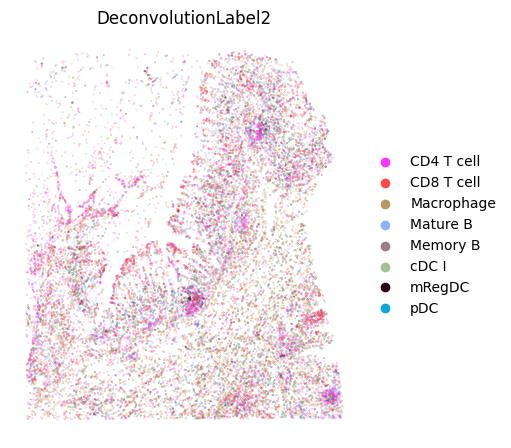

In [99]:
sq.pl.spatial_scatter(
    adata_immune,
    library_id="spatial",
    shape=None,
    color=[
        "DeconvolutionLabel2",
    ],
    wspace=0.4,
    size=0.02,
    figsize=(5, 5),
    frameon=False
)

/software/cellgen/team361/ms83/envs/env_Dec11th_mintflowandrapids/lib/python3.11/site-packages/squidpy/pl/_spatial_utils.py:982: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(


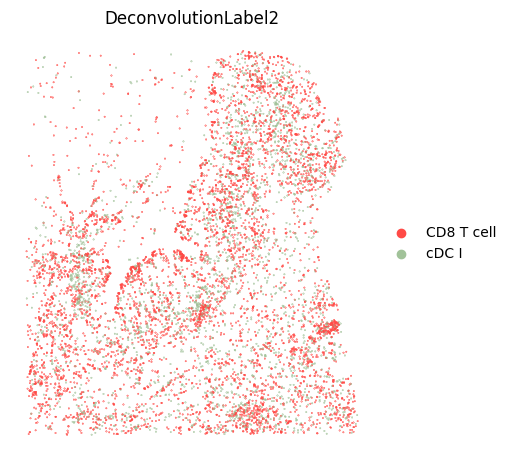

In [101]:
sq.pl.spatial_scatter(
    adata_immune,
    library_id="spatial",
    shape=None,
    color="DeconvolutionLabel2",
    groups=["cDC I", 'CD8 T cell'],   # cell type(s) of interest
    wspace=0.4,
    size=0.2,
    figsize=(5, 5),
    frameon=False
)

/software/cellgen/team361/ms83/envs/env_Dec11th_mintflowandrapids/lib/python3.11/site-packages/squidpy/pl/_spatial_utils.py:982: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(


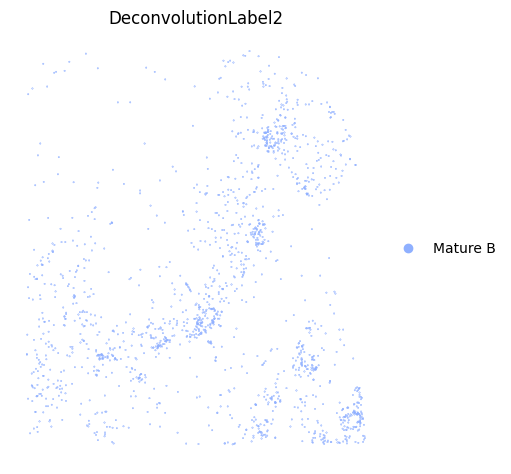

In [104]:
sq.pl.spatial_scatter(
    adata_immune,
    library_id="spatial",
    shape=None,
    color="DeconvolutionLabel2",
    groups=["Mature B"],   # cell type(s) of interest
    wspace=0.4,
    size=0.2,
    figsize=(5, 5),
    frameon=False
)